# Standard vs smooth-detuning MS gate: $\bar{n}$ sweep

This notebook compares the full-QPT infidelity of the current standard MS gate and the Hughes smooth-detuning gate at $\bar{n}=0.01,1,2,3,4$. All reusable functions are kept in `smooth_detuning_analysis.py`; this notebook only sets parameters, starts/resumes the calculation, and displays the saved results.

In [9]:
from pathlib import Path
import importlib

import pandas as pd
from IPython.display import Image, display

import smooth_detuning_analysis as sda
sda = importlib.reload(sda)

NBAR_VALUES = (0.01, 1.0, 2.0, 3.0, 4.0)
NOISE_CASE = 'all_noise'
SCATTERING_MODEL = 'constant_rate'
EXECUTE_QPT = True   # Full five-point master-equation/QPT sweep.
RESUME = True
PARALLEL_WORKERS = 1  # Increase only where multiprocessing is available.
OUTPUT_DIR = Path('results/smooth_detuning_nbar_sweep')

SWEEP_CONFIG = sda.NbarSweepConfig(
    nbar_values=NBAR_VALUES,
    noise_case=NOISE_CASE,
    scattering_model=SCATTERING_MODEL,
    standard_time_points=501,
    smooth_time_points=1501,
    standard_solver_max_step_s=0.2e-6,
    smooth_solver_max_step_s=0.05e-6,
    parallel_workers=PARALLEL_WORKERS,
    show_progress=True,
)
SWEEP_CONFIG

NbarSweepConfig(nbar_values=(0.01, 1.0, 2.0, 3.0, 4.0), noise_case='all_noise', scattering_model='constant_rate', standard_time_points=501, smooth_time_points=1501, standard_solver_max_step_s=2e-07, smooth_solver_max_step_s=5e-08, parallel_workers=1, random_seed=1234, show_progress=True, use_full_order=True)

## Execute or resume the sweep

The smooth pulse is calibrated once in the noise-free model, then the same calibrated pulse is fixed for all five temperatures. With `EXECUTE_QPT=False`, this cell only produces a fast first-order noise-free preview. Set it to `True` for the full master-equation/QPT result.

In [10]:
RESULT = sda.run_nbar_infidelity_sweep(
    output_dir=OUTPUT_DIR,
    smooth_config=sda.SmoothDetuningConfigSI(),
    standard_config=sda.StandardGateConfigSI(),
    sweep_config=SWEEP_CONFIG,
    execute_qpt=EXECUTE_QPT,
    resume=RESUME,
)
print('Output directory:', RESULT['output_dir'].resolve())
print('Calibrated delta_min/2pi:', RESULT['calibration']['delta_min_hz'], 'Hz')

Running standard: nbar=0.01, noise=all_noise


MS gate simulation (16 evolutions / n_bar):   0%|          | 0/16 [00:00<?, ?evolution/s]

Running standard: nbar=1.0, noise=all_noise


MS gate simulation (16 evolutions / n_bar):   0%|          | 0/16 [00:00<?, ?evolution/s]

Running standard: nbar=2.0, noise=all_noise


...

Running smooth_detuning: nbar=3.0, noise=all_noise


MS gate simulation (16 evolutions / n_bar):   0%|          | 0/16 [00:00<?, ?evolution/s]

Running smooth_detuning: nbar=4.0, noise=all_noise


MS gate simulation (16 evolutions / n_bar):   0%|          | 0/16 [00:00<?, ?evolution/s]

Output directory: /Users/hirainoa/Desktop/量子/project/Moon_shot__高橋PJ/MS_gate_Hirai/results/smooth_detuning_nbar_sweep
Calibrated delta_min/2pi: 22245.459873243974 Hz


## Results

`summary.csv` is the authoritative full-QPT result. The preview is explicitly labelled as a first-order, noise-free calculation and is not substituted for the noisy QPT sweep.

,pulse_type,nbar,F_avg,infidelity,delta_infidelity,improvement_factor,choi_min_eigenvalue,tp_error
0,smooth_detuning,0.01,0.997928,0.002072,0.000126,0.939429,2.435283e-07,2.009580e-15
5,standard,0.01,0.998054,0.001946,0.000000,1.000000,1.498470e-07,2.526749e-15
1,smooth_detuning,1.00,0.997030,0.002970,-0.000675,1.227128,3.873235e-07,2.759754e-15
6,standard,1.00,0.996356,0.003644,0.000000,1.000000,1.827426e-07,2.608792e-15
2,smooth_detuning,2.00,0.995433,0.004567,-0.001414,1.309574,5.283209e-07,2.359538e-15
7,standard,2.00,0.994019,0.005981,0.000000,1.000000,1.860777e-07,2.859710e-15
3,smooth_detuning,3.00,0.993210,0.006790,-0.002088,1.307448,7.742127e-07,5.243942e-15
8,standard,3.00,0.991122,0.008878,0.000000,1.000000,-4.662321e-08,2.245427e-15
4,smooth_detuning,4.00,0.990418,0.009582,-0.002699,1.281687,7.685788e-07,5.097780e-15
9,standard,4.00,0.987719,0.012281,0.000000,1.000000,1.172336e-07,3.855991e-15


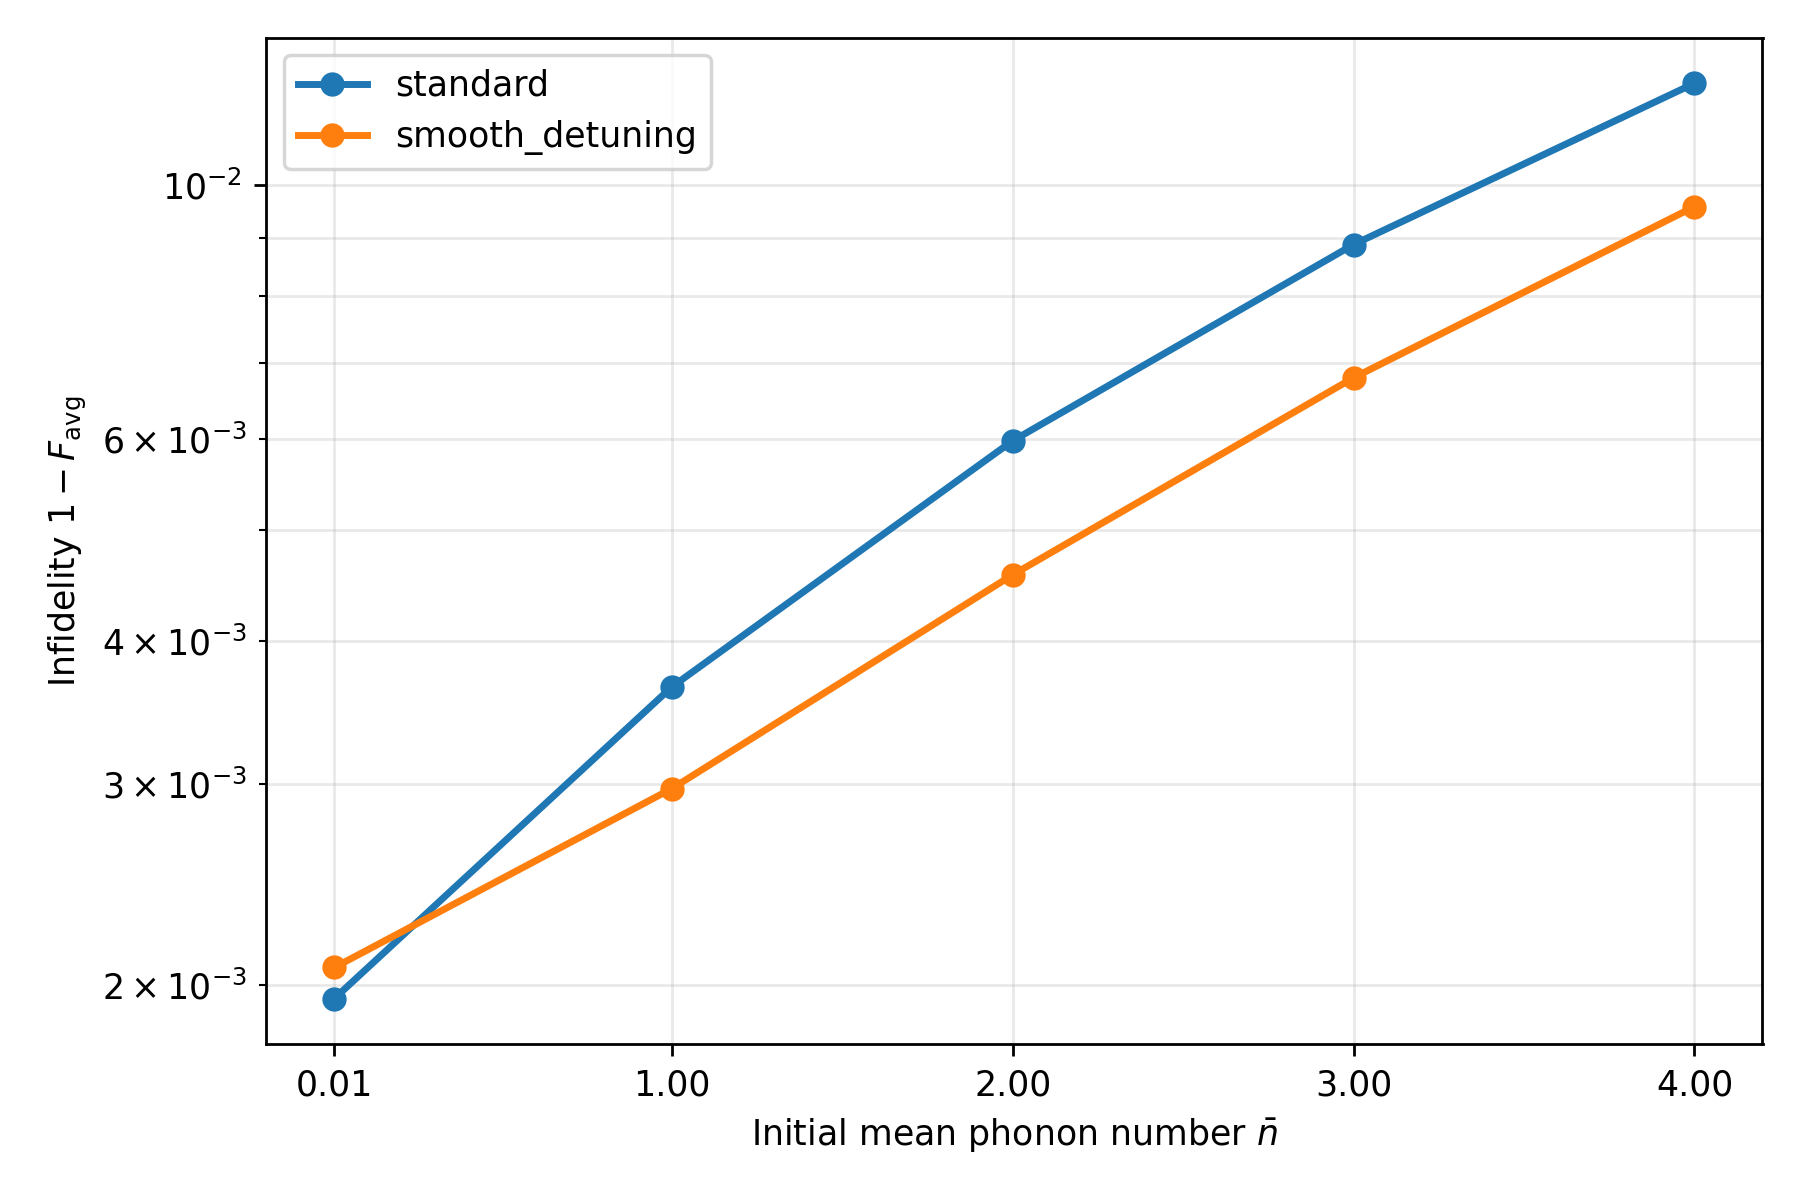

In [11]:
summary = RESULT['summary']
if summary.empty:
    print('Full QPT has not been run. Set EXECUTE_QPT=True and run all cells.')
    display(RESULT['analytic_preview'][['pulse_type', 'nbar', 'F_avg', 'infidelity']])
    display(Image(filename=str(OUTPUT_DIR / 'figures' / 'analytic_preview_infidelity_vs_nbar.png')))
else:
    columns = [
        'pulse_type', 'nbar', 'F_avg', 'infidelity',
        'delta_infidelity', 'improvement_factor',
        'choi_min_eigenvalue', 'tp_error',
    ]
    display(summary[columns].sort_values(['nbar', 'pulse_type']))
    display(Image(filename=str(OUTPUT_DIR / 'figures' / 'infidelity_vs_nbar.png')))

## Running instructions

1. For the full comparison, set `EXECUTE_QPT=True` and run all cells.
2. Leave `RESUME=True` after an interruption; every completed pulse/$\bar{n}$ condition is skipped.
3. If you change the noise model, scattering model, time grid, or $\bar{n}$ values, use a new output directory or set `RESUME=False`. Configuration mismatches are rejected instead of silently mixing results.
4. Outputs are saved under `results/smooth_detuning_nbar_sweep/`, including `summary.csv`, `pauli_probabilities.csv`, per-temperature channel NPZ files, and `figures/infidelity_vs_nbar.png`.